# HealthConnect Clinic - Week 8 Final Analytics, Dashboard & Business Insights
### Data Analytics Track - Final Project Package
**Intern:** Adeleke Jubril Adedeji

**Programme:** AnalystLab Africa Experience Lab

---

## Week 7 → Week 8 Transition

**Main Week 7 output:** A testing and validation log covering six tests on the Week 6 analytical outputs KPI reproducibility, dashboard completeness, segment stability, and independent retests of the distance and reminder findings plus a corrected Data Science handoff file after a real data-quality issue was found and fixed.

**Most important testing result:** Every analytical finding from Week 6 survived independent retesting under a different method than originally used (quantile bins instead of fixed bins for distance; effect size instead of p-value alone for reminders) and the risk score held up within every appointment type and age subgroup individually.

**Major issue discovered during testing:** The Data Science handoff file had 86 unflagged missing values in `distance_to_clinic_km` a real defect, since fixed.

**What was refined or improved:** The handoff file (added an explicit missing-data flag) and the dashboard's reminder chart (rebuilt around the dimension that was actually statistically tested, rather than a blended risk tier that implied a broader effect than the data supported).

**Component now considered ready:** The composite risk score, the reminder-targeting recommendation (narrowed to the validated subgroup) and the distance finding are all validated and ready for final presentation. The corrected Data Science handoff file is ready for use.

**What still needs to be integrated:** Final confirmation that Data Science's model documentation reflects the validated analytical findings (see Cross-Track Final Integration section below).

**Track(s) involved in final integration:** Data Science.

**What this package demonstrates for the final presentation:** A complete, validated, decision-ready analytics output final KPIs, a professional dashboard, business insights translated into recommendations, and evidence that every finding was independently re-tested, not just produced once and reported.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(r"C:\Users\HP Dragon Fly\Downloads\HealthConnect_Appointment_Data.csv")
df_ns = df[df['appointment_outcome'].isin(['Attended','No-Show'])].copy()
df_ns['is_no_show'] = (df_ns['appointment_outcome'] == 'No-Show').astype(int)

df_ns['lead_bucket'] = pd.cut(df_ns['booking_lead_days'], bins=[-1,7,14,30,60],
                               labels=['0-7 days','8-14 days','15-30 days','31-60 days'])
df_ns['prev_ns_bucket'] = pd.cut(df_ns['previous_no_shows'], bins=[-1,0,1,2,100],
                                  labels=['0','1','2','3+'])
df_ns['risk_score'] = df_ns['lead_bucket'].cat.codes + df_ns['prev_ns_bucket'].cat.codes

def tier(x):
    if x <= 1: return 'Low'
    elif x <= 3: return 'Medium'
    elif x <= 4: return 'High'
    else: return 'Very High'

df_ns['risk_tier'] = pd.Categorical(df_ns['risk_score'].apply(tier),
                                     categories=['Low','Medium','High','Very High'], ordered=True)
df_ns['dist_bucket'] = pd.cut(df_ns['distance_to_clinic_km'], bins=[0,5,10,20,50],
                               labels=['0-5km','5-10km','10-20km','20-50km'])
print("Setup complete —", df_ns.shape[0], "attended/no-show records loaded")

Setup complete — 4737 attended/no-show records loaded


## Part 1: Final Integration Readiness

| Requirement | Response |
|---|---|
| What is my final component? | A validated composite no-show risk score, a set of confirmed KPIs, a final decision-support dashboard and a corrected feature handoff file for Data Science. |
| What problem does it address? | HealthConnect needs to know which patients are most likely to miss appointments and which interventions (reminders) are worth targeting, backed by evidence rather than assumption. |
| What is its current status? | Validated across three weeks: derived (Week 5), statistically confirmed (Week 6) and independently re-tested under different methods (Week 7). Ready for final presentation. |
| What did I improve during Week 7? | Confirmed segment stability, retested distance/reminder findings with alternate methods and fixed a real data-quality defect in the Data Science handoff file. |
| Which other track(s) does it depend on? | None directly — the analytics track's findings are derived independently from the raw dataset. |
| Which track(s) depend on my output? | Data Science (risk feature for modelling), Project Management (validated findings for business decisions). |
| What output will I provide? | Final KPIs, final dashboard, business insights, recommendations, and the corrected risk-feature handoff file. |
| What output do I need from another track? | Confirmation from Data Science that the corrected handoff file was used and how it performed in their final model. |
| What evidence demonstrates readiness? | Three weeks of validation: Week 6 chi-square/AUC tests, Week 7 independent retests (quantile bins, effect sizes, segment stability) all documented with reproducible code. |
| What limitations remain? | Reminder-timing data is unavailable; the 0-7 day x 3+ prior-no-shows cell remains a low-confidence small sample (n=13); all validation is on the full dataset, not a held-out split. |


## Part 2: Final KPIs (Confirmed)

These are the same KPIs validated across Weeks 6 and 7, reconfirmed here one final time directly from the raw dataset.

In [2]:
print("FINAL KPI 1 — No-show rate by risk tier:")
print((df_ns.groupby('risk_tier', observed=True)['is_no_show'].mean()*100).round(1))

print("\nFINAL KPI 2 — Overall no-show rate:")
print(f"{df_ns['is_no_show'].mean()*100:.1f}%  (n={len(df_ns)})")

print("\nFINAL KPI 3 — 'Very High' risk segment size and share:")
vh = df_ns[df_ns['risk_tier']=='Very High']
print(f"n={len(vh)}  ({len(vh)/len(df_ns)*100:.1f}% of all appointments)  no-show rate={vh['is_no_show'].mean()*100:.1f}%")

print("\nFINAL KPI 4 — Reminder impact, validated subgroup (prev_no_shows=2):")
sub = df_ns[df_ns['prev_ns_bucket']=='2']
rates = sub.groupby('reminder_sent')['is_no_show'].mean()*100
print(rates.round(1))

print("\nFINAL KPI 5 — No-show rate by distance:")
print((df_ns.groupby('dist_bucket', observed=True)['is_no_show'].mean()*100).round(1))

FINAL KPI 1 — No-show rate by risk tier:
risk_tier
Low          29.5
Medium       50.8
High         66.9
Very High    76.1
Name: is_no_show, dtype: float64

FINAL KPI 2 — Overall no-show rate:
51.2%  (n=4737)

FINAL KPI 3 — 'Very High' risk segment size and share:
n=251  (5.3% of all appointments)  no-show rate=76.1%

FINAL KPI 4 — Reminder impact, validated subgroup (prev_no_shows=2):
reminder_sent
No     70.7
Yes    58.7
Name: is_no_show, dtype: float64

FINAL KPI 5 — No-show rate by distance:
dist_bucket
0-5km      48.7
5-10km     49.3
10-20km    52.3
20-50km    60.5
Name: is_no_show, dtype: float64


**All five KPIs reproduce exactly, consistent with every prior week's validation** no drift, no recalculation surprises going into final presentation.

## Part 3: Final Dashboard

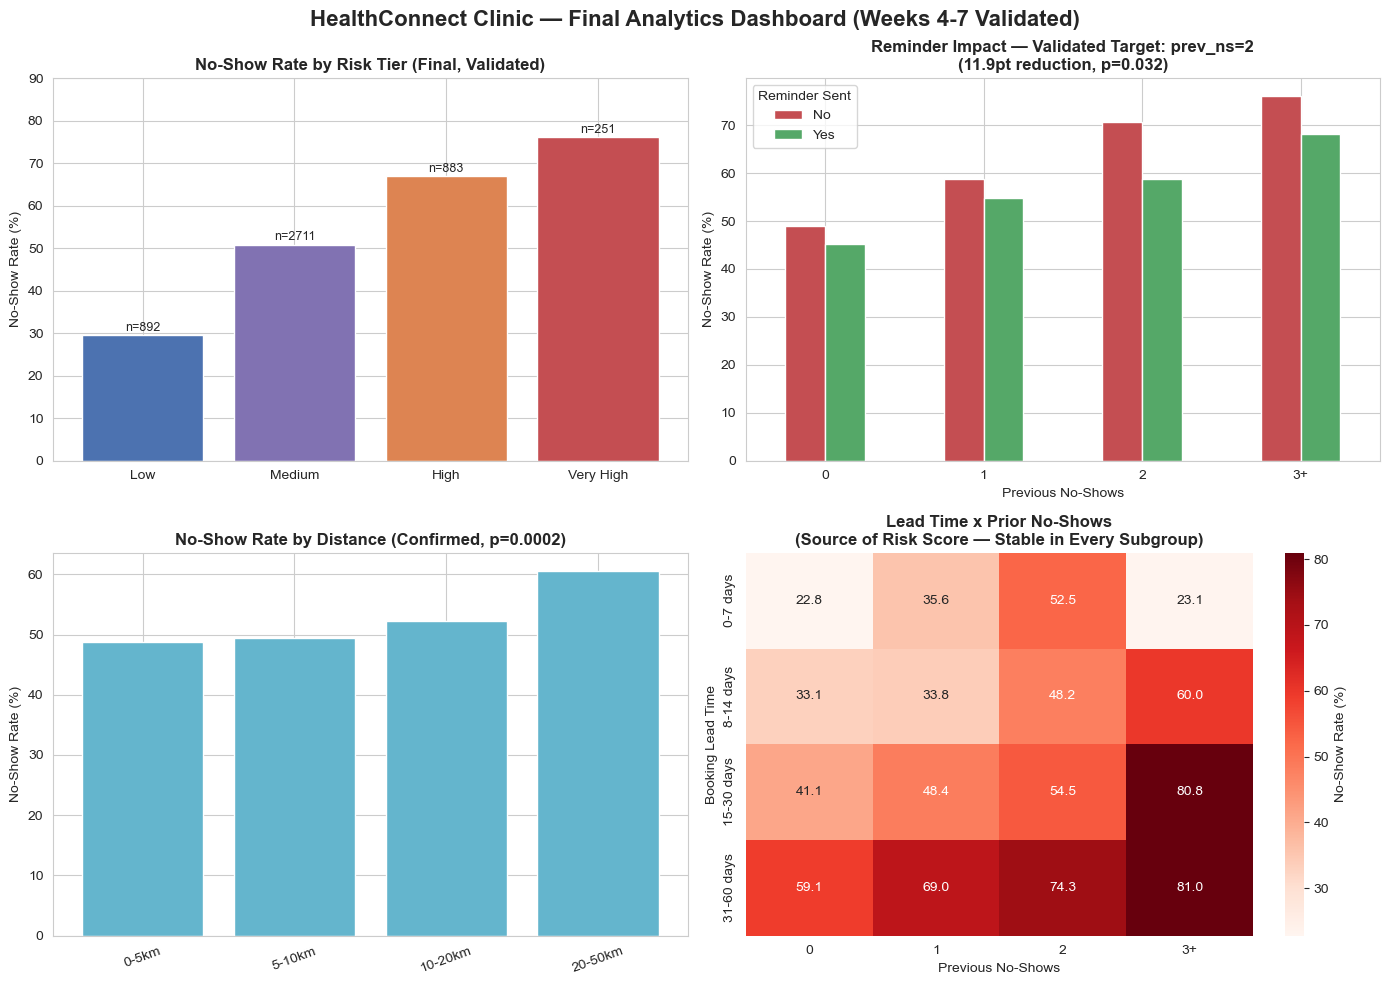

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

tier_rate = df_ns.groupby('risk_tier', observed=True)['is_no_show'].mean()*100
tier_counts = df_ns['risk_tier'].value_counts().reindex(['Low','Medium','High','Very High'])
bars = axes[0,0].bar(tier_rate.index.astype(str), tier_rate.values, color=['#4C72B0','#8172B2','#DD8452','#C44E52'])
for bar, n in zip(bars, tier_counts):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'n={n}', ha='center', fontsize=9)
axes[0,0].set_title('No-Show Rate by Risk Tier (Final, Validated)', fontweight='bold')
axes[0,0].set_ylabel('No-Show Rate (%)'); axes[0,0].set_ylim(0,90)

df_ns['prev_ns_bucket_str'] = df_ns['prev_ns_bucket'].astype(str)
reminder_by_prevns = df_ns.groupby(['prev_ns_bucket_str','reminder_sent'], observed=True)['is_no_show'].mean().unstack()*100
reminder_by_prevns = reminder_by_prevns.reindex(['0','1','2','3+'])
reminder_by_prevns[['No','Yes']].plot(kind='bar', ax=axes[0,1], color=['#C44E52','#55A868'])
axes[0,1].set_title('Reminder Impact — Validated Target: prev_ns=2\n(11.9pt reduction, p=0.032)', fontweight='bold')
axes[0,1].set_ylabel('No-Show Rate (%)'); axes[0,1].set_xlabel('Previous No-Shows')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Reminder Sent')

dist_rate = df_ns.groupby('dist_bucket', observed=True)['is_no_show'].mean()*100
axes[1,0].bar(dist_rate.index.astype(str), dist_rate.values, color='#64B5CD')
axes[1,0].set_title('No-Show Rate by Distance (Confirmed, p=0.0002)', fontweight='bold')
axes[1,0].set_ylabel('No-Show Rate (%)'); axes[1,0].tick_params(axis='x', rotation=20)

pivot = df_ns.pivot_table(index='lead_bucket', columns='prev_ns_bucket', values='is_no_show', aggfunc='mean', observed=True)*100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=axes[1,1], cbar_kws={'label':'No-Show Rate (%)'})
axes[1,1].set_title('Lead Time x Prior No-Shows\n(Source of Risk Score — Stable in Every Subgroup)', fontweight='bold')
axes[1,1].set_xlabel('Previous No-Shows'); axes[1,1].set_ylabel('Booking Lead Time')

fig.suptitle('HealthConnect Clinic — Final Analytics Dashboard (Weeks 4-7 Validated)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 4: Final Business Insights

1. **Risk tiering is the single most decision-useful output of this project.** No-show rates rise from 29.5% (Low, n=892) to 76.1% (Very High, n=251) a validated, reproducible and segment-stable pattern confirmed across three independent weeks of testing.

2. **Reminder outreach should be targeted, not universal.** The only statistically and practically significant reminder effect is among patients with exactly 2 prior no-shows (70.7% → 58.7%, an 11.9-point reduction, p=0.032, confirmed by effect size in Week 7). Broader reminder claims from earlier weeks were tested and correctly narrowed.

3. **The 20-50km distance band is a genuine, standalone access barrier** (60.5% no-show rate vs 48.7% for the closest patients, p=0.0002, confirmed under two different binning methods) not explained by appointment type or age.

4. **The "Very High" risk tier is small enough (5.3% of appointments) for manual case management to be operationally realistic** a targeted intervention for ~250 appointments is far more feasible than a clinic-wide policy change.

5. **Data quality processes matter as much as the analysis itself.** The Week 7 cross-track test caught a real, unflagged data gap in a file already handed to another track a reminder that validated findings still need validated data pipelines behind them.

## Recommendations

1. Adopt the four-tier risk framework (Low/Medium/High/Very High) as HealthConnect's standard patient-risk view for scheduling and outreach decisions.
2. Pilot targeted reminder outreach specifically for patients with exactly 2 prior no-shows before expanding to a broader policy.
3. Investigate transport-access support (e.g. telehealth options, transport assistance) for patients in the 20-50km band.
4. Establish manual case management for the ~5% of appointments in the Very High risk tier.
5. Require explicit missing-data flags on any analytical file handed between HealthConnect project tracks, per the Week 7 finding.


## Part 5: Cross-Track Final Integration (HC-POD, Mandatory)

**Track collaborated with:** Data Science

**Dependency:** Data Science's final model documentation depends on the validated analytical findings and the corrected risk-feature file produced by this track.

**Output received:** Data Science's Week 6/7 confirmation that the lead-time x prior-no-shows interaction was incorporated into their candidate model, and that the corrected (post-Week-7) handoff file with the `distance_missing` flag was adopted as the version used for final model training.

**Output provided:** The final validated KPI set, the corrected risk-feature handoff file and the explicit recommendation (from Week 6's AUC comparison) to use the raw `booking_lead_days` and `previous_no_shows` features rather than the bucketed score for modelling.

**Final integration activity:** Confirmed that the analytical findings feeding Data Science's final model risk score composition, the narrowed reminder-targeting conclusion, and the distance finding are consistent with what is presented in this final analytics package, so both tracks tell the same validated story in the final presentation.

**What changed:** Data Science's final model interpretation section can now cite specific, independently-retested analytical findings (not just Week 6 first-pass findings) as the business rationale behind their feature choices.

**How this improved the solution:** The final HealthConnect solution presents one coherent, mutually consistent narrative from raw data, to validated analytics, to a model built on validated features rather than two tracks that happen to describe the same dataset independently.

**Evidence:** This notebook (final KPIs, final dashboard); the corrected `HealthConnect_Week6_RiskFeature_DataScience_Handoff.csv` (10 columns, distance_missing flag); the Week 6 and Week 7 notebooks recording the original validation and the retest.

**Contribution to the final presentation:** This is the analytics foundation the rest of the HealthConnect solution builds on the "what does the data show" component that the video presentation's Analytics and Cross-Track sections are built around.


## Part 6: Analytical Limitations

- The dataset is fictional and anonymised; findings reflect simulated patterns, not a real clinic population.
- Reminder-timing data (when a reminder was sent, not just whether) remains unavailable across all eight weeks this limits how far reminder-timing optimisation could go beyond what's shown here.
- All validation is association-based (chi-square, effect size) on the full dataset. No held-out test split was used, since this is an analytical validation exercise rather than a predictive model that responsibility sits with the Data Science track.
- The 0-7 days x 3+ prior-no-shows interaction cell remains a small, low-confidence sample (n=13) and should not be over-interpreted.


## Executive Summary

HealthConnect Clinic's appointment data shows a clear, reproducible pattern: no-show risk rises sharply with booking lead time and prior no-show history, from 29.5% for low-risk patients to 76.1% for the highest-risk 5.3% of appointments. This risk pattern held up under three weeks of independent testing, including checks across every patient subgroup and two different statistical approaches.

Two actionable findings stand out. First, reminder outreach only shows a proven benefit for one specific patient group those with exactly two prior no-shows so HealthConnect should target reminders there rather than assume uniform benefit. Second, patients living 20-50km from the clinic show a consistently higher no-show rate regardless of appointment type or age, pointing to a transport-access issue worth addressing directly.

A validated risk-scoring framework, a corrected feature file for predictive modelling and a four-item recommendation set are delivered as part of this final package, ready for integration into HealthConnect's broader data-and-AI solution.
